# Regresión logística

## Introducción

El objetivo de este archivo es mostrar el desarrollo de regresión logística en el marco de machine learning y el modelo lineal general.

Cuando hablamos de regresión logística nos referimos a una tarea de predicción de una variable con múltiples categorías, lo cual es conocido como un problema de clasificación. En particular en este libro de notas nos restringiremos a la regresión logística binaria, en la que los posibles resultados de la variable predictora son solo dos, y se puede pensar en que la respuesta es una variable binomial.

##Data and business understanding

Trabajaremos con el contexto del archivo de cartera de empresas. Para mantener los libros de nota modulares, repetiré aquí el contexto:

In [1]:
if (!require('caret')) install.packages('caret')
if (!require('ROCR')) install.packages('ROCR')


Loading required package: caret

Warning message in library(package, lib.loc = lib.loc, character.only = TRUE, logical.return = TRUE, :
“there is no package called ‘caret’”
Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependencies ‘listenv’, ‘parallelly’, ‘future’, ‘globals’, ‘shape’, ‘future.apply’, ‘numDeriv’, ‘progressr’, ‘SQUAREM’, ‘diagram’, ‘lava’, ‘prodlim’, ‘proxy’, ‘iterators’, ‘clock’, ‘gower’, ‘hardhat’, ‘ipred’, ‘timeDate’, ‘e1071’, ‘foreach’, ‘ModelMetrics’, ‘plyr’, ‘pROC’, ‘recipes’, ‘reshape2’


Loading required package: ROCR

Warning message in library(package, lib.loc = lib.loc, character.only = TRUE, logical.return = TRUE, :
“there is no package called ‘ROCR’”
Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependencies ‘bitops’, ‘gtools’, ‘caTools’, ‘gplots’




In [2]:
library(caret)
library(ROCR)
library(ggplot2)
library(readxl)

Loading required package: ggplot2

Loading required package: lattice



In [3]:
cartera<-read_excel("carteraguia2017.xlsx")
str(cartera)

tibble [852 × 9] (S3: tbl_df/tbl/data.frame)
 $ MESES                   : num [1:852] 41 27 40 41 24 41 39 43 24 36 ...
 $ TIPO_ips                : num [1:852] 3 1 1 1 2 2 1 1 1 1 ...
 $ IGUAL_DUENO             : num [1:852] 17 10 15 15 2 5 20 12 3 0 ...
 $ AGNOS_DIRECCION_ACTUAL  : num [1:852] 12 6 14 14 0 5 9 11 4 13 ...
 $ VENTAS_MENS_PROMEDIO    : num [1:852] 176 31 55 120 28 25 67 38 19 25 ...
 $ PORC_PASIVOS_VENTA_ANUAL: num [1:852] 9.3 17.3 5.5 2.9 17.3 10.2 30.6 3.6 24.4 19.7 ...
 $ cartera_actual_insumos_A: num [1:852] 11.359 1.362 0.856 2.659 1.787 ...
 $ cartera_actual_insumos_B: num [1:852] 5.009 4.001 2.169 0.821 3.057 ...
 $ retrasos                : num [1:852] 1 0 0 0 1 0 0 0 1 0 ...


El archivo contiene datos de clientes de un proveedor de instituciones de salud (IPS), la cartera que presentan y si se han retrasado o no. Se trata entonces de un negocio B2B en el sector de la salud que desea predecir o averiguar indicadores de posibles aumentos y retrasos en su cartera

Entre las variables predictoras se incluyen:


*   Tipo_IPS: De 1 a5, el nivel de complejidad de la institución de salud cliente (1=bajo, 5=alto)

*   MESES: Los meses que la empresa lleva siendo clientes del proveedor.

*   IGUAL_DUEÑO: Número de años en que la IPS ha tenido el mismo dueño.

*   AGNOS_DIRECCION_ACTUAL: Número de años en que la IPS ha estado en la misma dirección.

*   VENTAS_MENS_PROMEDIO: Valor de ventas mensuales promedio de la IPS en millones de pesos.

*   PORC_PASIVOS_VENTA_ANUAL: Porcentaje de pasivos/ venta anual del último balance disponible.


*   CARTERA_ACTUAL_INSUMOS_A: Valor de la deuda con el proveedor en insumos de alta rotación (gasa, jeringas, por ejemplo) en millones de pesos.

*   CARTERA_ACTUAL_INSUMOS_B: Valor de la deuda con el proveedor en insumos de baja rotación (equipos, instrumentos, por ejemplo) en millones de pesos.



La variable a predecir son los RETRASOS, que indican sí el cliente se ha retrasado o no, siendo 1=sí y 0=No.

##Data preparation

Primero vamos a convertir a factores las dos variables que lo requieren: Tipo IPS y retrasos. También vamos a crear variables binarias para los tipos de IPS y luego retirar la variable TIPO IPS.

In [4]:
cartera$TIPOips<-as.factor(cartera$TIPO_ips)
cartera$retrasos<-as.factor(cartera$retrasos)

Si se desea se puede realizar una exploración básica de las variables independientes antes de separarlas en bases de entrenamiento y validación, lo que se deja al lector.

De todos modos, es importante ver la proporción de retrasos vs. no retrasos. En caso de que una de las clases, usualmente la clase que más interesa predecir, tenga un porcentaje mucho menor que la otra (digamos, menos del 20%) es necesario un balanceo de la base de datos.

In [5]:
balance<-table(cartera$retrasos)
prop.table(balance)


        0         1 
0.7734742 0.2265258 

Incialmente no es necesario un balanceo, pero podemos considerarlo más adelante si queremos que el algoritmo “aprenda” más sobre los retrasos.

Creemos bases de entrenamiento y validación

In [6]:
set.seed(1545867)
#aquí se define el tamaño de la muestra, en este caso entrenamiento tendrá el 75% de los casos

In [7]:
sample <- sample.int(nrow(cartera), floor(.75*nrow(cartera)))
cartera.train <- cartera[sample, ]
cartera.test <- cartera[-sample, ]

## Modelling

Ahora podemos hacer un modelo de regresión logística basado en pasos sucesivos:

In [8]:
##Modelo
modelo.logit<-glm(retrasos~.,family=binomial,cartera.train)
#trace=0 impide ver todos los detalles de la optimización stepwise
steplogit<-step(modelo.logit, direction="both")
summary(steplogit)

Start:  AIC=480.55
retrasos ~ MESES + TIPO_ips + IGUAL_DUENO + AGNOS_DIRECCION_ACTUAL + 
    VENTAS_MENS_PROMEDIO + PORC_PASIVOS_VENTA_ANUAL + cartera_actual_insumos_A + 
    cartera_actual_insumos_B + TIPOips


Step:  AIC=480.55
retrasos ~ MESES + IGUAL_DUENO + AGNOS_DIRECCION_ACTUAL + VENTAS_MENS_PROMEDIO + 
    PORC_PASIVOS_VENTA_ANUAL + cartera_actual_insumos_A + cartera_actual_insumos_B + 
    TIPOips

                           Df Deviance    AIC
- TIPOips                   4   462.40 478.40
- MESES                     1   456.67 478.67
<none>                          456.55 480.55
- PORC_PASIVOS_VENTA_ANUAL  1   458.60 480.60
- cartera_actual_insumos_B  1   459.66 481.66
- VENTAS_MENS_PROMEDIO      1   462.39 484.39
- AGNOS_DIRECCION_ACTUAL    1   465.78 487.78
- cartera_actual_insumos_A  1   493.56 515.56
- IGUAL_DUENO               1   497.84 519.84

Step:  AIC=478.4
retrasos ~ MESES + IGUAL_DUENO + AGNOS_DIRECCION_ACTUAL + VENTAS_MENS_PROMEDIO + 
    PORC_PASIVOS_VENTA_ANUAL 


Call:
glm(formula = retrasos ~ IGUAL_DUENO + AGNOS_DIRECCION_ACTUAL + 
    VENTAS_MENS_PROMEDIO + PORC_PASIVOS_VENTA_ANUAL + cartera_actual_insumos_A + 
    cartera_actual_insumos_B, family = binomial, data = cartera.train)

Coefficients:
                         Estimate Std. Error z value Pr(>|z|)    
(Intercept)              -0.69660    0.52902  -1.317  0.18791    
IGUAL_DUENO              -0.20369    0.03212  -6.342 2.27e-10 ***
AGNOS_DIRECCION_ACTUAL   -0.06688    0.02127  -3.145  0.00166 ** 
VENTAS_MENS_PROMEDIO     -0.02267    0.01457  -1.555  0.11986    
PORC_PASIVOS_VENTA_ANUAL  0.06475    0.03603   1.797  0.07232 .  
cartera_actual_insumos_A  0.56443    0.12390   4.556 5.22e-06 ***
cartera_actual_insumos_B  0.13401    0.10268   1.305  0.19185    
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

(Dispersion parameter for binomial family taken to be 1)

    Null deviance: 674.45  on 638  degrees of freedom
Residual deviance: 462.57  on 632  degrees of freedo

La devianza debería disminuir sustancialmente desde la nula hacia la residual.

Los coeficientes de la regresión logística pueden ser sujeto de interpretación en términos de odd ratios.

In [9]:
coeficientes<-steplogit$coefficients
odd_change<-exp(coeficientes)
odd_change_ver<-as.data.frame(odd_change)
odd_change_ver

,odd_change
,<dbl>
(Intercept),0.4982771
IGUAL_DUENO,0.8157168
AGNOS_DIRECCION_ACTUAL,0.9353077
VENTAS_MENS_PROMEDIO,0.9775869
PORC_PASIVOS_VENTA_ANUAL,1.0668911
cartera_actual_insumos_A,1.7584489
cartera_actual_insumos_B,1.1434074


### odd ratios

Los coeficientes, denominados odd ratios indican que:

Cada mes con el mismo dueño, dejando todas las demás variables constantes, reduce al 81.6% el odd base de que el cliente incumpla, es decir, reduce la probabilidad de incumplimiento (la reducción exacta en probabilidad la veremos más adelante).

Cada año en la dirección actual reduce el odd base al 93.6%. Cada millón de venta mensual promedio reduce el odd base al 97.8%

En la otra dirección están las variables que aumentan el incumplimiento: Por cada punto porcentual de pasivo/venta anual aumenta el odd base en 6.7%, mientras que cada millon que adeuda al proveedor en cartera  aumenta el odd base de incumplimiento, cuando es de  baja rotación (A) en 75.8% y es de alta rotación (B) en 14.3%

Para entender mejor los odd ratios es necesario primero tener clara la tasa base. Ese valor es la proporción de éxitos en la base de datos (en este caso siendo éxito un retraso). Esto ya lo obtuvimos en la tabla vista previamente y que aquí repetimos. De allí, podemos calcular un odd base.

In [10]:
#Odd ratios
balance<-table(cartera$retrasos)
prop.table(balance)
oddbase<-prop.table(balance)[2]/prop.table(balance)[1]
oddbase


        0         1 
0.7734742 0.2265258 

1 
0.292868

Si el odd base es de 0.29 (y la probabilidad inicial de incumplimiento de 22.65%), podemos multiplicar los odd ratios por esa tase base y luego convertirla a probabilidad:

In [11]:
oddfin<-oddbase*odd_change
prob1step<-as.data.frame(oddfin/(1+oddfin))
View(prob1step)

,oddfin/(1 + oddfin)
,<dbl>
(Intercept),0.1273459
IGUAL_DUENO,0.1928306
AGNOS_DIRECCION_ACTUAL,0.2150224
VENTAS_MENS_PROMEDIO,0.2225787
PORC_PASIVOS_VENTA_ANUAL,0.2380710
cartera_actual_insumos_A,0.3399311
cartera_actual_insumos_B,0.2508619


De ese modo vemos, por ejemplo, que aumentar un año el cliente en la dirección actual (con todo lo demás constante) reduce la probabilidad de incumplimiento al 21.5%, mientras que el primer millón adicional de cartera en insumos A la aumenta al 33.99%.
Estos aumentos o disminuciones en probabilidad no son lineales. El segundo y tercer año (o el segundo y tercer millón) no genera exactamente el mismo aumento y disminución. De hecho, se genera una curva de tipo “s”.

Creemos una base de datos para ver eso:

In [12]:
#crear matriz vacia
oddprueba<-matrix(,6,29)
probprueba<-matrix(,6,29)

In [13]:
#borrar el intercepto
odd_change2<-odd_change[-1]

In [14]:
#guardar odd base y probabilidad base
oddprueba[,11]<-oddbase
probprueba[,11]<-oddprueba[,11]/(1+oddprueba[,11])

In [15]:
#calcular odds y probabilidades 17 pasos adelante
for (i in 12:29){
  oddprueba[,i]<-oddprueba[,i-1]*odd_change2
  probprueba[,i]<-oddprueba[,i]/(1+oddprueba[,i])
}

In [16]:
#y 10 atrás
for (i in 10:1){
  oddprueba[,i]<-oddprueba[,i+1]/odd_change2
  probprueba[,i]<-oddprueba[,i]/(1+oddprueba[,i])
}

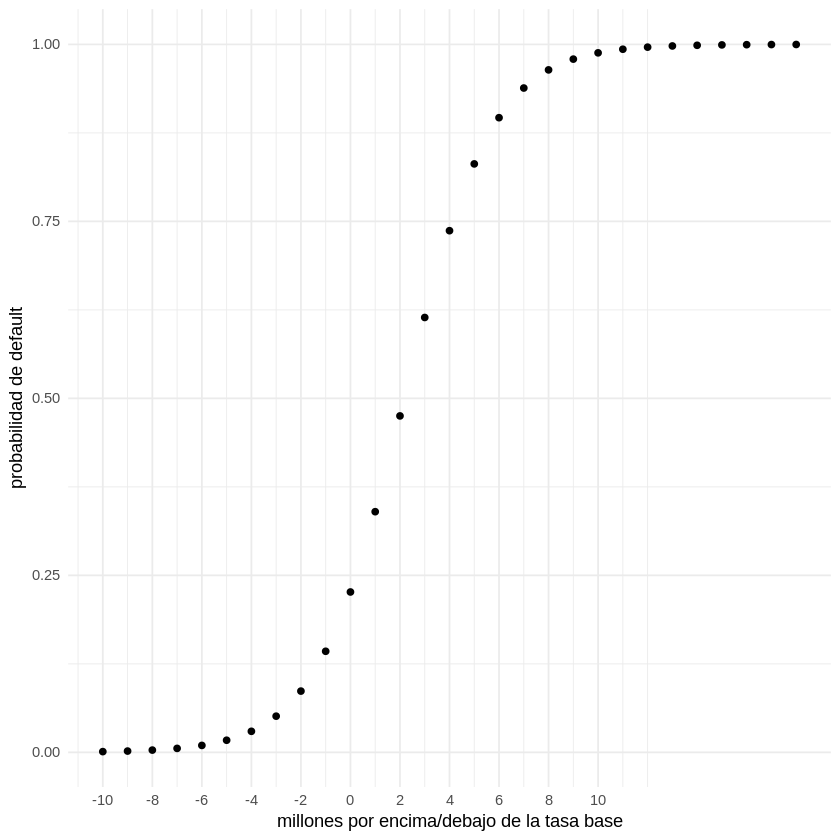

In [17]:
#guardar en un dataframe
probver<-as.data.frame(t(probprueba))
#crear id y graficar: cartera insumos A
probver$id<-seq(1:29)-11
names(probver)<-c("años igual dueño","años dirección actual","ventas promedio", "%pasivo/ venta anual","cartera insumos A", "cartera insumos B", "pasos")
ggplot(probver, aes(x=pasos,y=`cartera insumos A`))+geom_point()+labs(x="millones por encima/debajo de la tasa base",y="probabilidad de default")+scale_x_continuous(breaks=c(-10,-8,-6,-4,-2,0,2,4,6,8,10))+theme_minimal()
#plot(probver$pasos, probver$`cartera insumos A`)

## Evaluación

Para la evaluación de un problema de clasificación se utilizan con mucha frecuencia las matrices de confusión, que permiten ver la precision y la exhaustividad (precision and recall)

Las haremos suponiendo que una predicción superior a 0.5 indica incumplimiento, y una predicción inferior o igual a 0.5 indica cumplimiento

In [18]:
#crea el pronostico base de entrenamiento
prontrain<-ifelse(steplogit$fitted.values > 0.5,1,0)
#tabla de confusión y estad?sticas, base de entrenamiento
conftrain<-confusionMatrix(as.factor(prontrain),cartera.train$retrasos, positive = "1")
conftrain$table


          Reference
Prediction   0   1
         0 475  78
         1  23  63

In [19]:
as.data.frame(conftrain$byClass)

,conftrain$byClass
,<dbl>
Sensitivity,0.44680851
Specificity,0.95381526
Pos Pred Value,0.73255814
Neg Pred Value,0.85895118
Precision,0.73255814
Recall,0.44680851
F1,0.55506608
Prevalence,0.22065728
Detection Rate,0.09859155


In [20]:
#crea el pronóstico en validación
probtest<-predict(steplogit,newdata = cartera.test,type='response')
prontest<-ifelse(probtest > 0.5,1,0)
conftest<-confusionMatrix(as.factor(prontest),cartera.test$retrasos, positive = "1")
conftest$table


          Reference
Prediction   0   1
         0 151  34
         1  10  18

In [21]:
as.data.frame(conftest$byClass)

,conftest$byClass
,<dbl>
Sensitivity,0.34615385
Specificity,0.93788820
Pos Pred Value,0.64285714
Neg Pred Value,0.81621622
Precision,0.64285714
Recall,0.34615385
F1,0.45000000
Prevalence,0.24413146
Detection Rate,0.08450704


En la base de datos de prueba, la precisión es del 64.3% y la exhaustividad de 34.6%. La precisión es qué tanto acierta el modelo cuando dice que una empresa generará incumplimiento. La exahustividad es cuántas de las empresas incumplidas son detectadas como tales.UNa combinación de los dos es el F1 score, que para nuestro caso es de 45%. Se puede aumentar la precisión disminuyendo la exhaustividad y viceversa, cambiando simplemente el punto de corte (disminuyéndolo para aumentar precisión o aumentándolo para aumentar exhaustividad)

Para observar ese balance se utiliza la curva COR (o ROC por sus siglas en inglés). Al graficar la curva de todas las posibles combinaciones de falsos positivos (que hablan de la precisión) contra los verdaderos positivos (que hablan de la exhaustividad) podemos darnos una idea de cómo funcionaría el modelo en diferentes puntos de corte. El área bajo la curva dibujada es un indicador adicional de la calidad del modelo

In [22]:
##nuevo sobre precision
cartllev<-cbind(cartera.test,probtest)

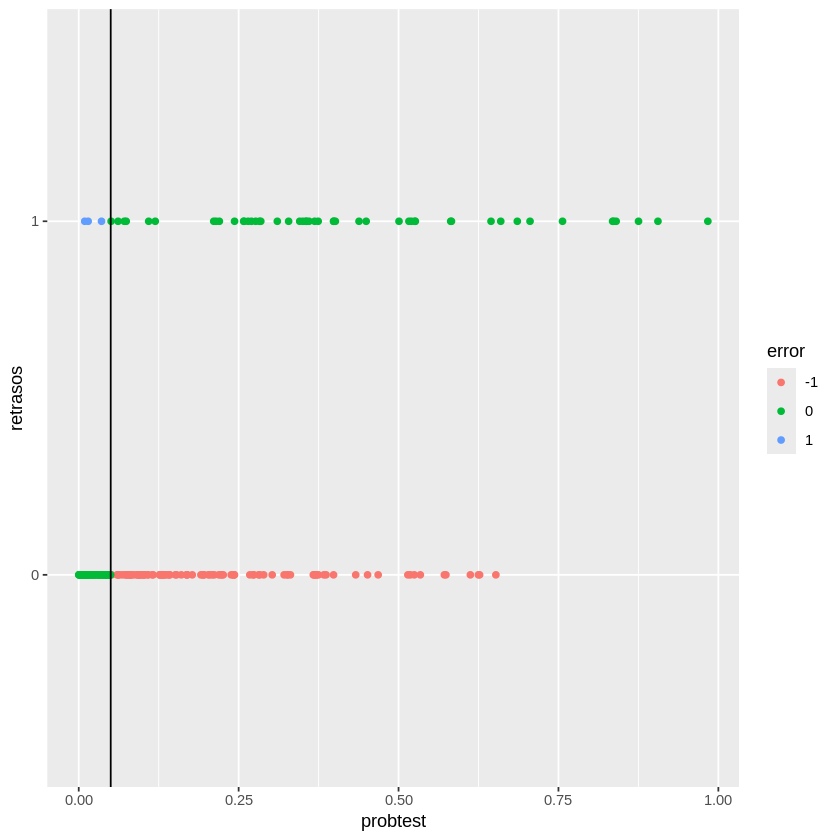

In [23]:
corte<-0.05
cartllev$pronostico<-as.factor(ifelse(cartllev$probtest>corte,1,0))
cartllev$error<-as.factor(as.numeric(cartllev$retrasos)-as.numeric(cartllev$pronostico))
ggplot(cartllev,aes(probtest,retrasos, color=error))+geom_point()+geom_vline(xintercept=corte)

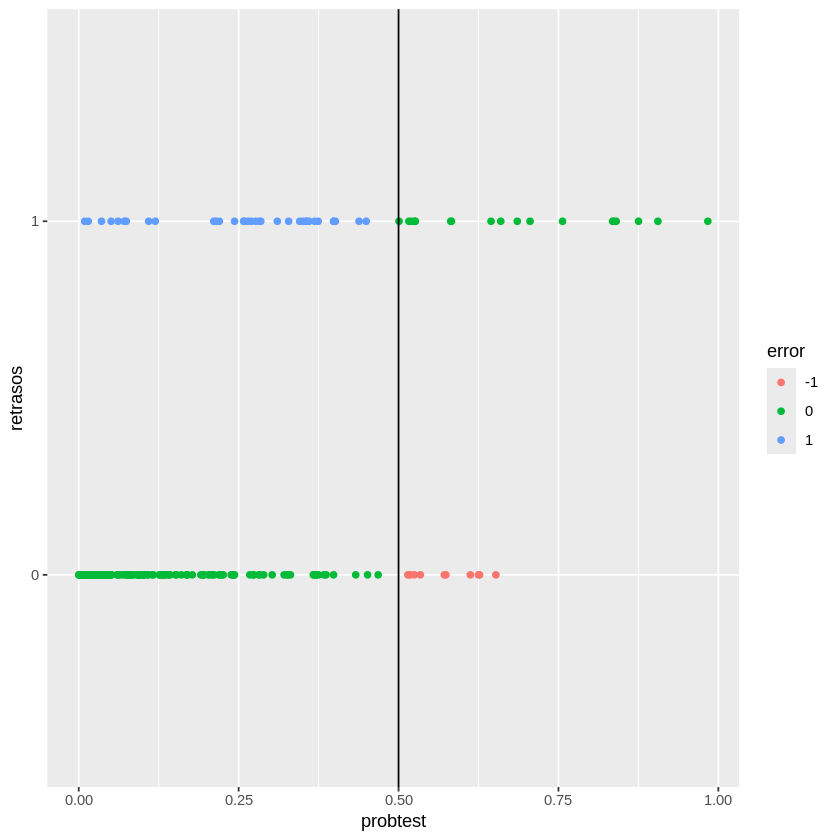

In [24]:
corte<-0.5
cartllev$pronostico<-as.factor(ifelse(cartllev$probtest>corte,1,0))
cartllev$error<-as.factor(as.numeric(cartllev$retrasos)-as.numeric(cartllev$pronostico))
ggplot(cartllev,aes(probtest,retrasos, color=error))+geom_point()+geom_vline(xintercept=corte)

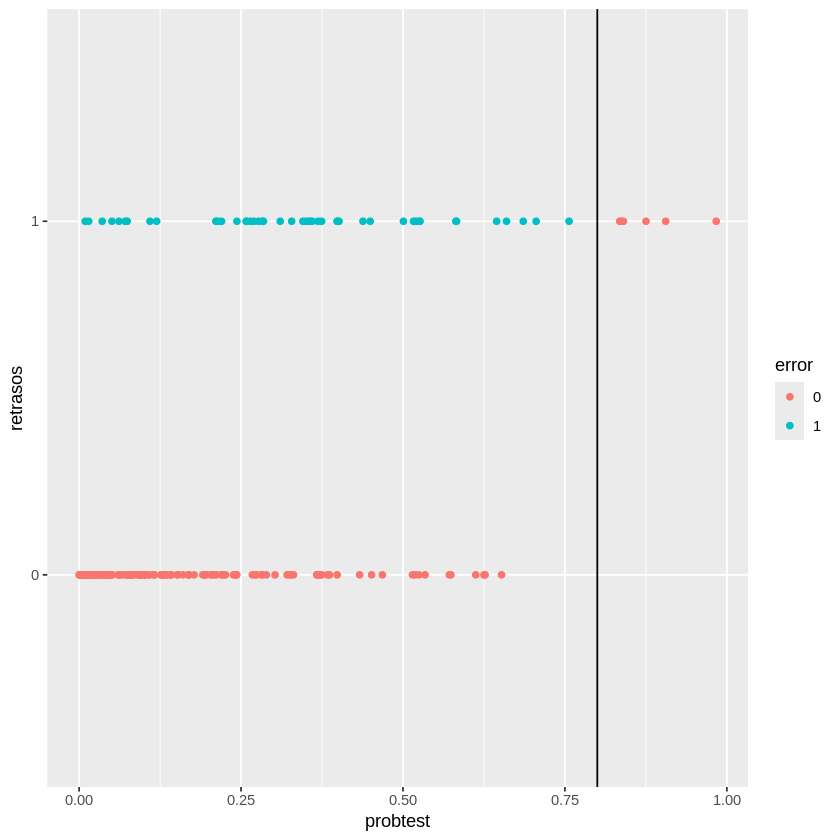

In [25]:
corte<-0.8
cartllev$pronostico<-as.factor(ifelse(cartllev$probtest>corte,1,0))
cartllev$error<-as.factor(as.numeric(cartllev$retrasos)-as.numeric(cartllev$pronostico))
ggplot(cartllev,aes(probtest,retrasos, color=error))+geom_point()+geom_vline(xintercept=corte)

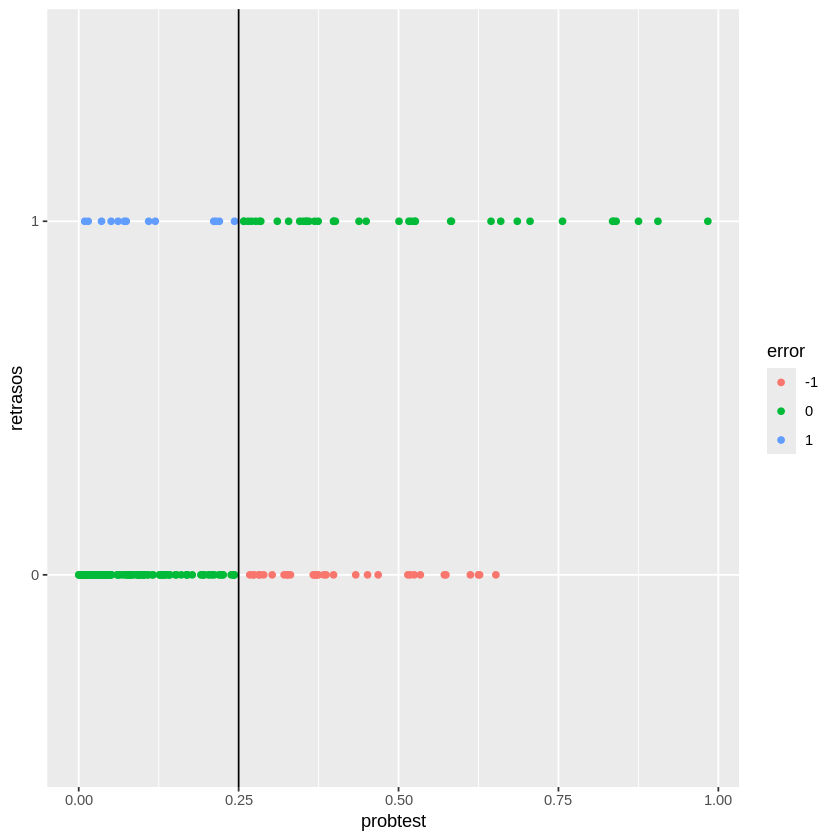

In [26]:
corte<-0.25
cartllev$pronostico<-as.factor(ifelse(cartllev$probtest>corte,1,0))
cartllev$error<-as.factor(as.numeric(cartllev$retrasos)-as.numeric(cartllev$pronostico))
ggplot(cartllev,aes(probtest,retrasos, color=error))+geom_point()+geom_vline(xintercept=corte)

In [27]:
#crear objeto de predicciones
pr<-prediction(probtest,cartera.test$retrasos)
#creacion del objeto de la curva
curvaROC<-performance(pr,measure="tpr",x.measure="fpr")

[1] 0.8093645

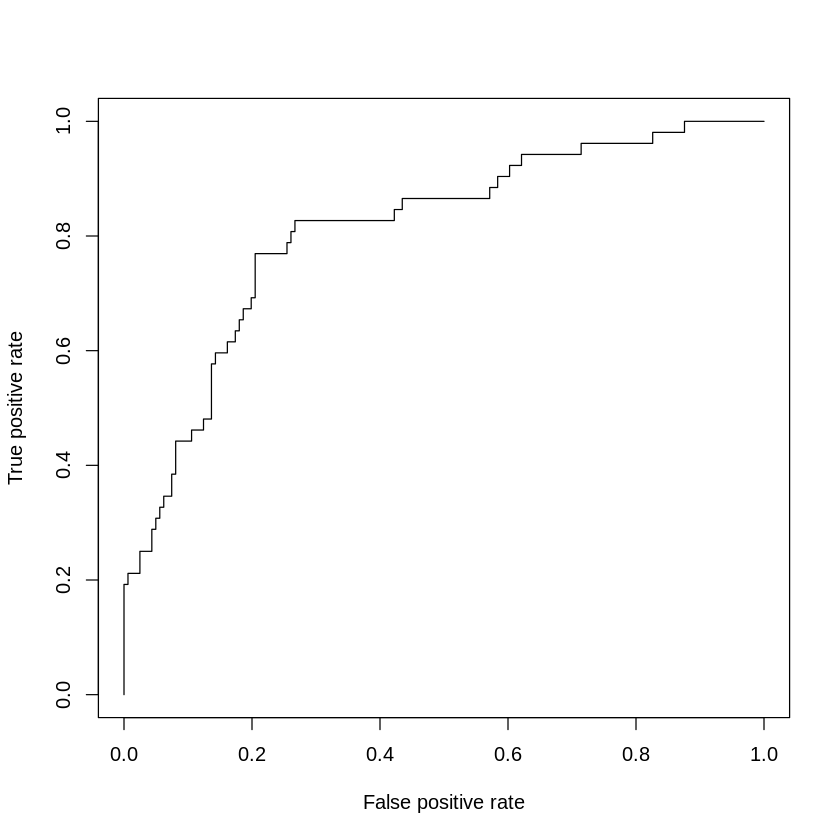

In [28]:
#grafico de la curva
plot(curvaROC)
#calcular el AUC
auc<-performance(pr,measure = "auc")
auc <- auc@y.values[[1]]
#ver el AUC
auc

El area bajo la curva es de 80.9%, lo cual está bien por encima del 50% de una predicción al azar.

La curva COR muestra que para lograr un 80% de exhaustividad (tomar acciones sobre el 80% de los incumplidos), tendríamos que aceptar un 26% de falsos positivos (en lenguaje de negocios, tendríamos que “tocar o incomodar” al 26% de clientes que van a ser cumplidos)

De hecho, esos valores exactos son 26.1% y 80.8%. La tabla completa puede obtenerse de la siguiente manera:

In [29]:
fprs<-unlist(curvaROC@x.values)
tprs<-unlist(curvaROC@y.values)
tablaCOR<-as.data.frame(cbind(fprs,tprs))
tablaCOR[70:95,]

,fprs,tprs
,<dbl>,<dbl>
70,0.2049689,0.6923077
71,0.2049689,0.7115385
72,0.2049689,0.7307692
73,0.2049689,0.7500000
74,0.2049689,0.7692308
75,0.2111801,0.7692308
76,0.2173913,0.7692308
77,0.2236025,0.7692308
78,0.2298137,0.7692308


La curva de ganancias (gain) permite ver a qué porcentaje de la base de datos hay que mirar para obtener un porcentaje dado de casos positivos

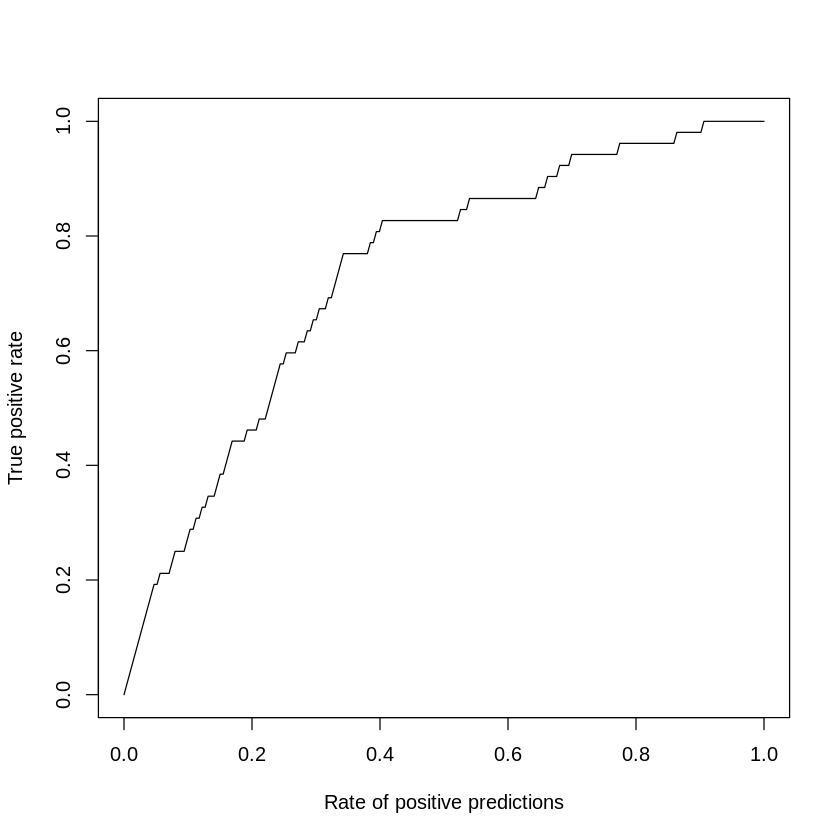

In [30]:
gain<-performance(pr, "tpr", "rpp")
plot(gain)

Vemos que con el 10% de la base de datos con puntajes más altos obtenemos cerca del  25% de los incumplidos (grupo objetivo)

## Evaluación financiera

Los valores de capacidad predictiva (y de error) deben ser vistos a la luz del negocio. Eso significa, usualmente, traducirlos en términos de costo/beneficio.

Ahi suele ser clave trabajar para maximizar la ganancia.

Para ello es importante definir los beneficios que nos trae un acierto y las pérdidas que nos genera un error.

Supongamos que un acierto nos permite ganancias (a 1 año) de 700 (mil pesos) y en cambio un fracaso nos hace perder un primer negocio de aproximadamente 100 (mil pesos). Vamos a suponer que el porcentaje de éxitos posibles es similar al de la base de datos completa.

Podemos crear una base de precisiones y exhaustividades que, basadas en la ecuación vista en clase, nos permitan calcular ganancias para diferentes puntos de corte:

In [31]:
#guardar las exhaustividades y puntos de corte
tablafinan<-performance(pr,measure="rec")
cutoffs<-unlist(tablafinan@x.values)
recalls<-unlist(tablafinan@y.values)

In [32]:
#guardar las precisiones
tablafina2<-performance(pr,measure="prec")
precisions<-unlist(tablafina2@y.values)

In [33]:
#guardar f scores
tablafina3<-performance(pr,measure="f")
fscores<-unlist(tablafina3@y.values)

In [34]:
#crear la tabla conjunta
tablacruce<-as.data.frame(cbind(cutoffs,precisions,recalls,fscores))

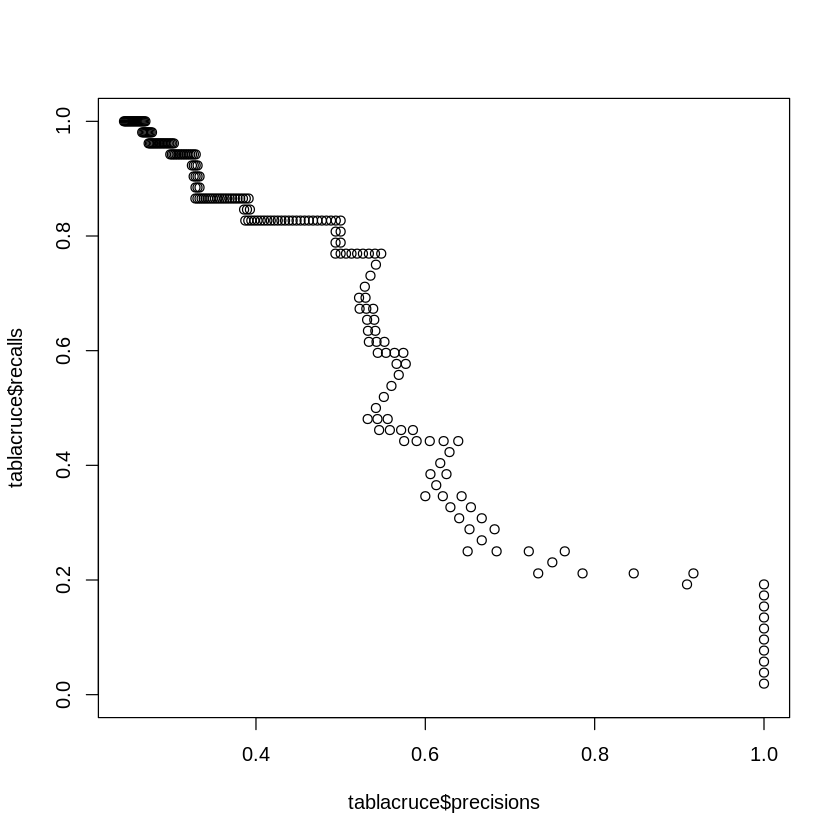

In [35]:

#ver precisiones versus exhaustividad
plot(tablacruce$precisions,tablacruce$recalls)

Warning message:
“Removed 1 row containing missing values or values outside the scale range
(`geom_point()`).”


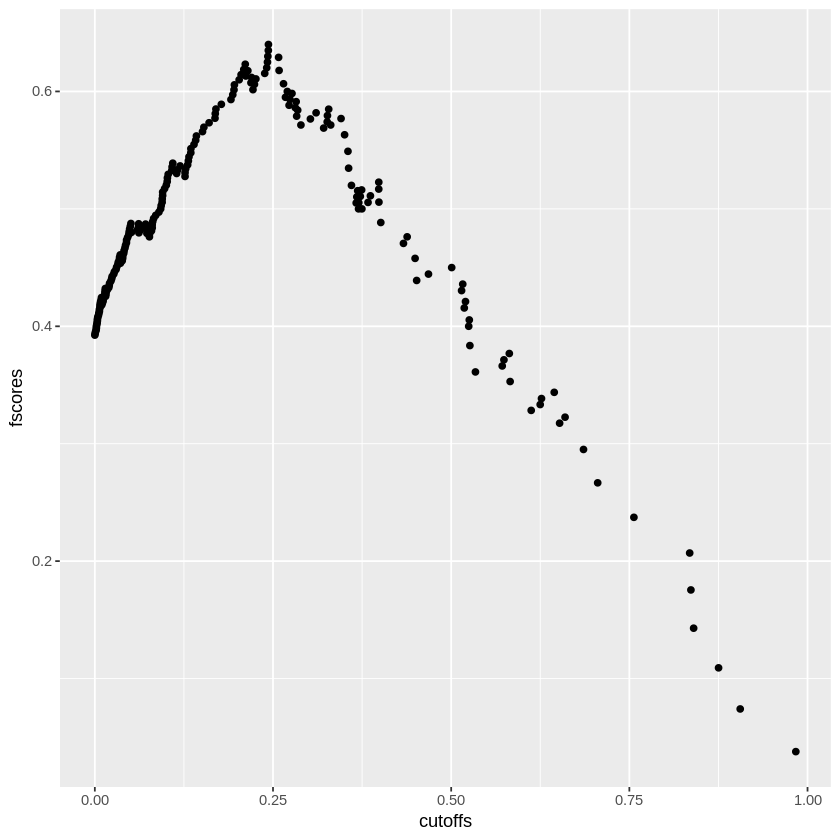

In [36]:
#ver el cutoff que maximiza f score
ggplot(tablacruce, aes(cutoffs,fscores))+geom_point()


In [37]:
#calcular las ganancias
tablacruce$wins<-prop.table(balance)[2]*recalls*(700-(100/precisions))

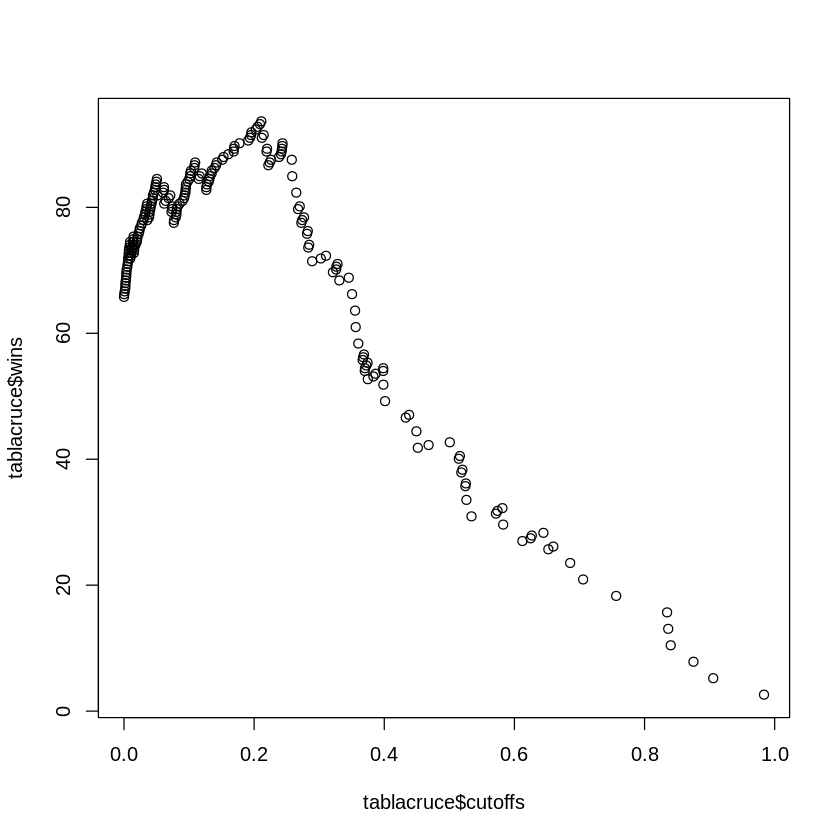

In [38]:
#pintar las ganancias versus los cutoffs
plot(tablacruce$cutoffs,tablacruce$wins)

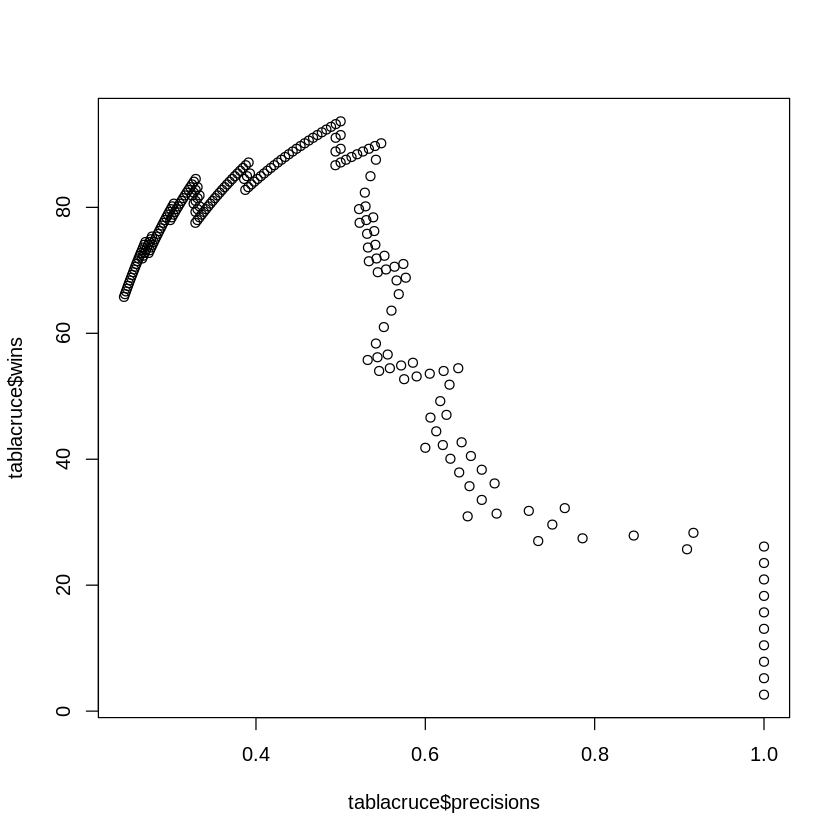

In [39]:
#ver las ganancias frente a la precisión
plot(tablacruce$precisions,tablacruce$wins)

La primera gráfica nos muestra la relación inversa entre precisiones y exhaustividades.

La segunda gráfica nos muestra el cambio en F score según el punto de corte, donde el punto de corte que máxima el F score es de 25%
La tercera gráfica nos presenta las ganancias (por cliente) contra los puntos de corte, de modo que podemos escoger un punto de corte ideal, el cual, para las ganancias y pérdidas presentadas está cercano a 0.2.

La cuarta gráfica nos muestra la relación de ganancias con precisones, donde es visible que no necesariamente la mayor precisión lleva a la mejor ganancia (por su baja exhaustividad)

Por supuesto, estos resultados dependen de la definición de ganancias y pérdidas. Si el costo de un cliente que incumple, por ejemplo, es del 70% frente a la ganancia que puede traer un cliente cumplido, entonces la precisión actual no es suficiente y debemos cambiar el punto de corte o buscar un balanceo de la base de datos que permita realizar mejores predicciones de incumplidos.

In [40]:
tablaver<-subset(tablacruce, tablacruce$cutoffs>0.13 & tablacruce$cutoffs<0.22)
View(tablaver)

,cutoffs,precisions,recalls,fscores,wins
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,0.2198646,0.5000000,0.7884615,0.6119403,89.30345
170,0.2190635,0.4939759,0.7884615,0.6074074,88.86782
38,0.2146966,0.5000000,0.8076923,0.6176471,91.48158
11,0.2118538,0.4941176,0.8076923,0.6131387,91.04596
138,0.2110727,0.5000000,0.8269231,0.6231884,93.65971
86,0.2089611,0.4942529,0.8269231,0.6187050,93.22409
55,0.2052135,0.4886364,0.8269231,0.6142857,92.78846
173,0.2024994,0.4831461,0.8269231,0.6099291,92.35283
62,0.1958244,0.4777778,0.8269231,0.6056338,91.91721


## Balanceo

Una posibilidad para aprender más sobre los incumplimientos (1 en la base de datos) es generando muestras de tal modo que la base de entrenamiento tenga 50% de cada clase, y la base de prueba, en lo posible, un porcentaje no tocado de la base de datos con las proporciones originales de cumplimientos e incumplimientos (1s y 0s) . Esto puede hacerse retirando casos positivos de la base de entrenamiento (undersampling) o remuestreándolos de forma que se aumenten hasta alcanzar el balance (oversampling). La generación de muestras debe hacerse obligatoriamente *después* de separar la base de prueba, con el fin de evitar la filtración de datos de entrenamiento hacia prueba.  
Para esto usaremos la librería ROSE que ya trae ambos métodos implementados (aunque el balance tiende a no quedar perfecto, si bien se acerca)

In [41]:
if (!require('ROSE')) install.packages('ROSE')

Loading required package: ROSE

Warning message in library(package, lib.loc = lib.loc, character.only = TRUE, logical.return = TRUE, :
“there is no package called ‘ROSE’”
Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



In [42]:
library(ROSE)

Loaded ROSE 0.0-4




In [54]:
##ajusto el p porque el 50% no está logrando el balance adecuado
cartera.train.over<-ovun.sample(retrasos~.,data=cartera.train,method="over",p=0.49,seed=398)$data
cartera.train.under<-ovun.sample(retrasos~.,data=cartera.train,method="under",seed=398)$data

In [50]:
table(cartera.train$retrasos)


  0   1 
498 141 

In [55]:
table(cartera.train.over$retrasos)


  0   1 
498 501 

In [56]:
table(cartera.train.under$retrasos)


  0   1 
147 141 

In [57]:
prop.table(table(cartera$retrasos))
prop.table(table(cartera.train.over$retrasos))
prop.table(table(cartera.train.under$retrasos))



        0         1 
0.7734742 0.2265258 


        0         1 
0.4984985 0.5015015 


        0         1 
0.5104167 0.4895833 

Vemos que la base de entrenamiento queda cerca al  50%-50% de casos, y la de test es la misma original

exploremos

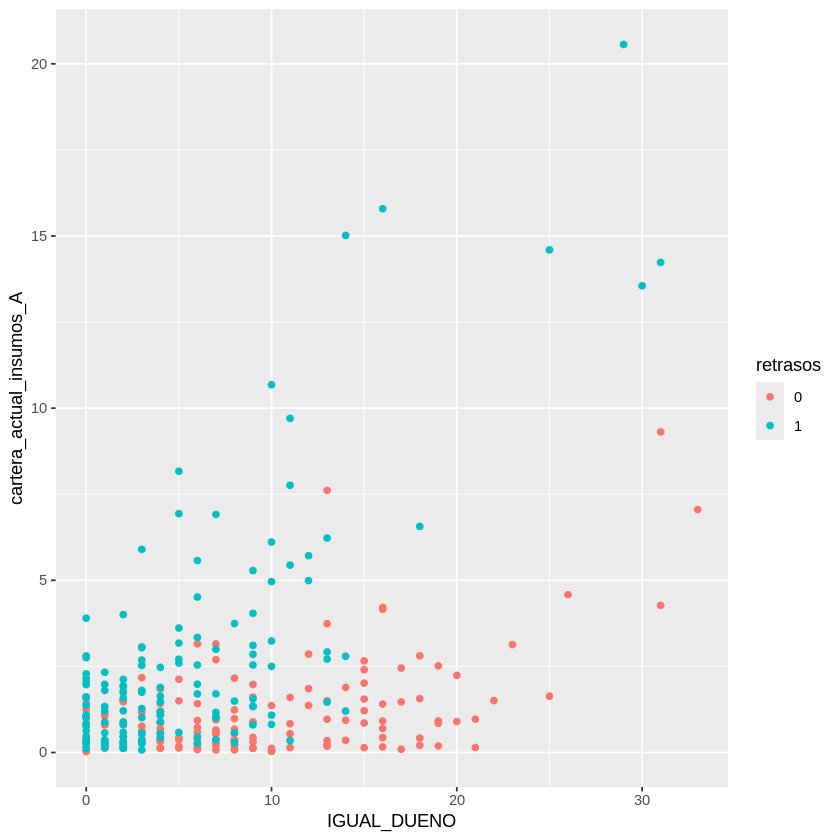

In [58]:
ggplot(cartera.train.under,aes(x=IGUAL_DUENO, y=cartera_actual_insumos_A,color=retrasos))+geom_point()

El gráfico es más visible que con la base de datos original, que tendría más puntos de cumplidos que de incumplidos.

Hagamos un modelo con el oversampling:

In [61]:
modelo.balance<-glm(retrasos~.,family=binomial,cartera.train.under)

In [62]:
#trace=0 impide ver todos los detalles de la optimización stepwise
stepbalance<-step(modelo.balance, direction="both", trace=0)
summary(stepbalance)


Call:
glm(formula = retrasos ~ IGUAL_DUENO + AGNOS_DIRECCION_ACTUAL + 
    PORC_PASIVOS_VENTA_ANUAL + cartera_actual_insumos_A, family = binomial, 
    data = cartera.train.under)

Coefficients:
                         Estimate Std. Error z value Pr(>|z|)    
(Intercept)              -0.16971    0.36536  -0.465 0.642285    
IGUAL_DUENO              -0.22012    0.03772  -5.836 5.34e-09 ***
AGNOS_DIRECCION_ACTUAL   -0.06994    0.02669  -2.621 0.008775 ** 
PORC_PASIVOS_VENTA_ANUAL  0.09540    0.02835   3.365 0.000766 ***
cartera_actual_insumos_A  0.57233    0.14172   4.039 5.38e-05 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

(Dispersion parameter for binomial family taken to be 1)

    Null deviance: 399.13  on 287  degrees of freedom
Residual deviance: 265.96  on 283  degrees of freedom
AIC: 275.96

Number of Fisher Scoring iterations: 5


Note que las variables predictoras cambiaron. Cuatro se mantuvieron (pasivos, igual dueño, años en dirección actual y cartera A) pero 2 ya no quedaron en el modelo (ventas promedio y cartera B). Miremos los odds

In [63]:
coeficientes2<-stepbalance$coefficients
odd_changeb<-exp(coeficientes2)
odd_changeb

(Intercept)              IGUAL_DUENO   AGNOS_DIRECCION_ACTUAL 
               0.8439088                0.8024223                0.9324542 
PORC_PASIVOS_VENTA_ANUAL cartera_actual_insumos_A 
               1.1000949                1.7723955

Cada año con el mismo dueño disminuyen el odd de ser incumplido al 84.4% , cada millón de cartera A aumenta ese odd en 77.2% y cada punto porcentual de pasivo aumenta el odd en 10.0%. Miremos sus métricas de desempeño en prueba:

In [66]:
#crea el pronóstico en validación
probtest2<-predict(stepbalance,newdata = cartera.test,type='response')
prontest2<-ifelse(probtest2 > 0.5,1,0)
conftest2<-confusionMatrix(as.factor(prontest2),cartera.test$retrasos, positive = "1")
conftest2$table

          Reference
Prediction   0   1
         0 125  12
         1  36  40

In [67]:
as.data.frame(conftest2$byClass)


,conftest2$byClass
,<dbl>
Sensitivity,0.7692308
Specificity,0.7763975
Pos Pred Value,0.5263158
Neg Pred Value,0.9124088
Precision,0.5263158
Recall,0.7692308
F1,0.6250000
Prevalence,0.2441315
Detection Rate,0.1877934


Nótese que la precisión baja (al 52.6%) pero la exhaustividad sube (al 76.9%). El F score, con punto de corte en 0.5 es de 62.5%, superior al del anterior modelo.

 Y en cuanto a AUC?

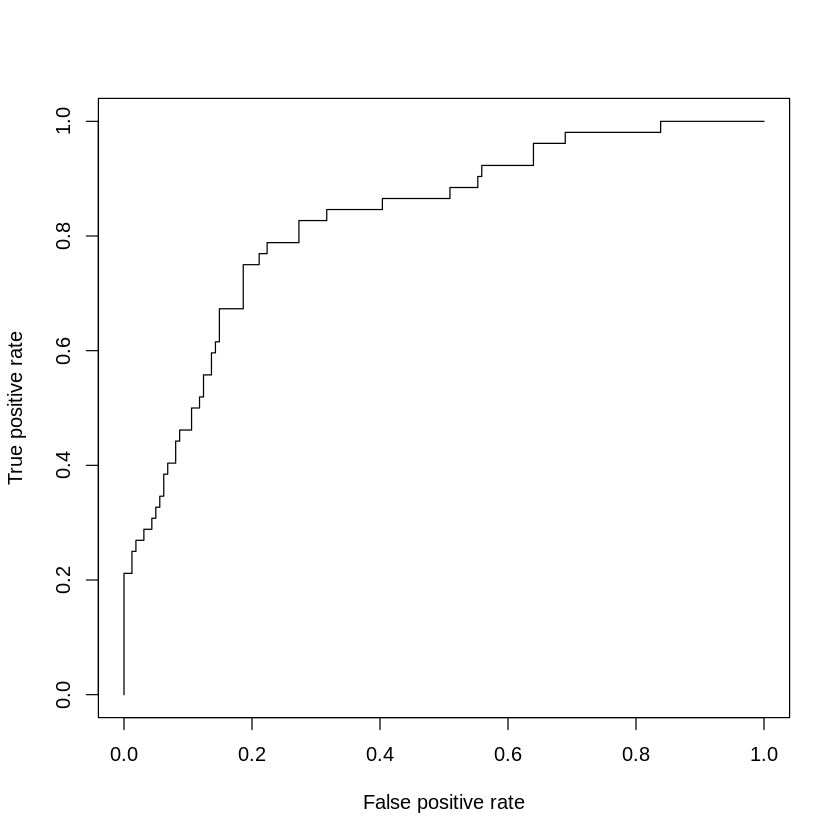

In [68]:
#crear objeto de predicciones
pr2<-prediction(probtest2,cartera.test$retrasos)
#creacion del objeto de la curva
curvaROC2<-performance(pr2,measure="tpr",x.measure="fpr")
#grafico de la curva
plot(curvaROC2)

In [69]:
#calcular el AUC
auc2<-performance(pr2,measure = "auc")
auc2f <- auc2@y.values[[1]]
#ver el AUC
auc2f

[1] 0.8272814

Nuestro AUC ahora es del 82.7% (una leve mejora), y ahora el modelo está sesgado en la búsqueda de incumplidos. ¿Que pasará si se hace el modelo con oversampling?



In [70]:
modelo.balanceover<-glm(retrasos~.,family=binomial,cartera.train.over)
stepbalance2<-step(modelo.balanceover, direction="both", trace=0)
summary(stepbalance2)


Call:
glm(formula = retrasos ~ MESES + IGUAL_DUENO + AGNOS_DIRECCION_ACTUAL + 
    VENTAS_MENS_PROMEDIO + PORC_PASIVOS_VENTA_ANUAL + cartera_actual_insumos_A + 
    TIPOips, family = binomial, data = cartera.train.over)

Coefficients:
                          Estimate Std. Error z value Pr(>|z|)    
(Intercept)              -0.847938   0.409053  -2.073  0.03818 *  
MESES                     0.038081   0.012471   3.053  0.00226 ** 
IGUAL_DUENO              -0.221250   0.023816  -9.290  < 2e-16 ***
AGNOS_DIRECCION_ACTUAL   -0.100553   0.017130  -5.870 4.36e-09 ***
VENTAS_MENS_PROMEDIO     -0.012999   0.005923  -2.195  0.02819 *  
PORC_PASIVOS_VENTA_ANUAL  0.099122   0.016258   6.097 1.08e-09 ***
cartera_actual_insumos_A  0.534564   0.078204   6.836 8.17e-12 ***
TIPOips2                  0.321209   0.195595   1.642  0.10055    
TIPOips3                  0.756942   0.272248   2.780  0.00543 ** 
TIPOips4                  0.026070   0.388880   0.067  0.94655    
TIPOips5                  1

In [72]:
probtest3<-predict(stepbalance2,newdata = cartera.test,type='response')
prontest3<-ifelse(probtest3 > 0.5,1,0)
conftest3<-confusionMatrix(as.factor(prontest3),cartera.test$retrasos, positive = "1")
conftest3$table
as.data.frame(conftest3$byClass)

          Reference
Prediction   0   1
         0 122  12
         1  39  40

,conftest3$byClass
,<dbl>
Sensitivity,0.7692308
Specificity,0.7577640
Pos Pred Value,0.5063291
Neg Pred Value,0.9104478
Precision,0.5063291
Recall,0.7692308
F1,0.6106870
Prevalence,0.2441315
Detection Rate,0.1877934


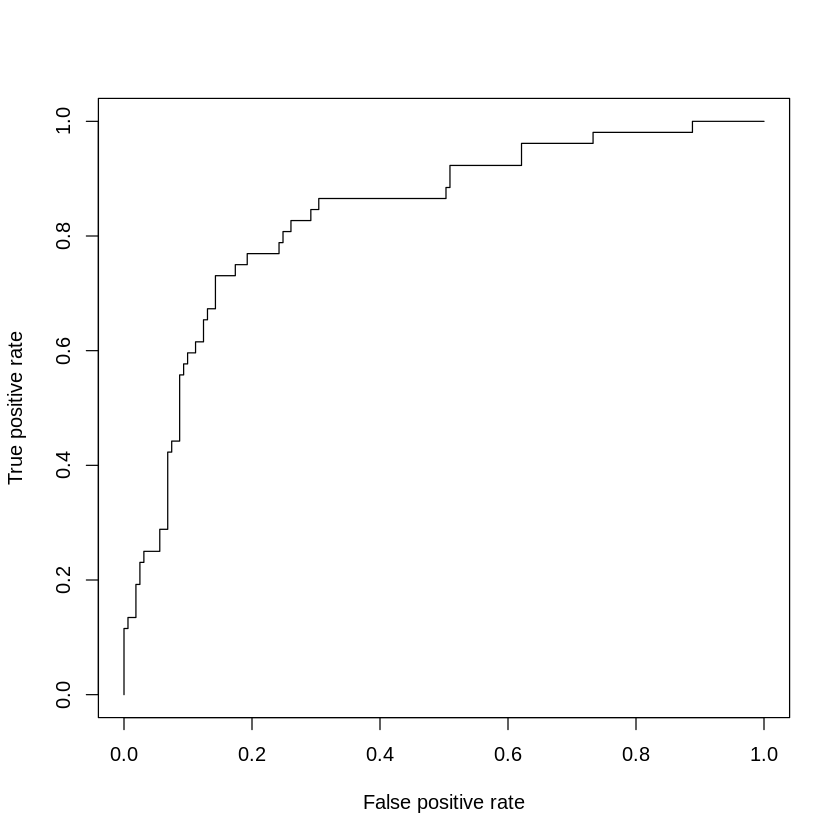

In [73]:
#crear objeto de predicciones
pr3<-prediction(probtest3,cartera.test$retrasos)
#creacion del objeto de la curva
curvaROC3<-performance(pr3,measure="tpr",x.measure="fpr")
#grafico de la curva
plot(curvaROC3)

In [74]:
#calcular el AUC
auc3<-performance(pr3,measure = "auc")
auc3f <- auc3@y.values[[1]]
#ver el AUC
auc3f

[1] 0.8357621

El modelo incluye más variables (algo más de riesgo de overfitting). Sus métricas son ligeramente mejores que en undersampling en test, con un AUC del 83.6%
En este libro de notas hemos realizado modelos de regresión logística binaria para clasificación, y hemos podido revisar aspectos básicos de evaluación de dichos modelos (incluyendo la parte financiera) y la posibilidad de generar un sesgo de balance para aprender más de una clase que nos interesa más.